In [ ]:
# @title
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
  !pip install unsloth
else:
  import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
  xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
  !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
  !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth pillow
  !pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
!pip install "huggingface_hub>=1.5.0,<2.0"
!pip install torchcodec
!pip install -q -U deepeval
!pip install anthropic
!git clone https://github.com/EvolvingLMMs-Lab/lmms-eval.git
%cd /content/lmms-eval
!pip install -e ".[all]"

In [ ]:
# @title
from unsloth import FastVisionModel, get_chat_template
from unsloth.trainer import UnslothVisionDataCollator
import io
import gc
import sys
import peft
import glob
import json
import shutil
import base64
import transformers
import pandas as pd
from PIL import Image
from pathlib import Path
from peft import PeftModel
import matplotlib.pyplot as plt
from collections import Counter
from huggingface_hub import login
from trl import SFTTrainer, SFTConfig
from transformers import TextStreamer
from safetensors.torch import load_file
from datetime import datetime, timezone
from google.colab import drive, userdata
from datasets import load_dataset, Dataset
from transformers.trainer_utils import get_last_checkpoint
from transformers import AutoProcessor, AutoModelForMultimodalLM

from lmms_eval.api.model import lmms
from lmms_eval.api.registry import register_model
from lmms_eval.protocol import ChatMessages

from deepeval import evaluate
from deepeval.models import GeminiModel
from deepeval.test_case import LLMTestCase, MLLMImage, SingleTurnParams, LLMTestCaseParams
from deepeval.metrics import GEval, AnswerRelevancyMetric, FaithfulnessMetric


torch._dynamo.config.recompile_limit = 64;

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("PEFT:", peft.__version__)
print("CUDA:", torch.cuda.is_available())

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch: 2.11.0+cu128
Transformers: 5.5.0
PEFT: 0.20.0
CUDA: True


In [ ]:
# @title
!rm -rf /root/.cache/huggingface

!rm -rf /root/.cache/pip
!rm -rf /tmp/*

!du -sh /root/.cache/* /tmp/* /content/* 2>/dev/null | sort -hr | head -20

56M	/root/.cache/node-gyp
55M	/content/sample_data
48M	/content/lmms-eval
32K	/root/.cache/matplotlib
8.0K	/root/.cache/antigravity


In [ ]:
MODEL_NAME="Gemma-4-31B-it"
BASE_MODEL=f"unsloth/{MODEL_NAME}"
TIMESTAMP=datetime.now(timezone.utc).strftime("%Y-%B-%d_%H:%M")
MAX_LENGTH=1024
RANK=16
MAX_STEPS=100
NUM_TRAIN_EPOCHS=1
LEARNING_RATE=2e-5
RUN_NAME = f"{MODEL_NAME}_{RANK}_{TIMESTAMP}"

In [ ]:
# @title
drive.mount('/content/drive')

HEA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/HEA")
OUTPUT_DIR = HEA_DIR / "gemma4" / "outputs" / f'{RANK}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = OUTPUT_DIR / "logs"

PLOT_DIR = OUTPUT_DIR / "plots"
ADAPTER_PATH = OUTPUT_DIR / "gemma4_31b_high-entropy-alloy_lora"

training_plots_img = PLOT_DIR / "training_plots.png"
training_plots_pdf = PLOT_DIR / "training_plots.pdf"
training_log_dir = LOG_DIR / "training_log.json"

lora_stats_img = PLOT_DIR / "lora_stats.png"
lora_stats_pdf = PLOT_DIR / "lora_stats.pdf"
gpu_stats_file = LOG_DIR / "gpu_stats.json"

lmms_eval_img = PLOT_DIR / "lmms_eval_img.png"
lmms_eval_pdf = PLOT_DIR / "lmms_eval_pdf.pdf"
lmms_eval_xlsx = PLOT_DIR / "lmms_eval.xlsx"

deepeval_img = PLOT_DIR / "deepeval_img.png"
deepeval_pdf = PLOT_DIR / "deepeval_pdf.pdf"
deepeval_xlsx = PLOT_DIR / "deepeval.xlsx"


HF_HUB_DIR = "eneotu/gemma4_e2b_high-entropy-alloy_lora"
data_dir = HEA_DIR / "high-entropy-alloy-sem-dataset"

base_lmms_eval_dir = LOG_DIR / "base_lmms_eval"
fine_tuned_lmms_eval_dir = LOG_DIR / "ft_lmms_eval"

login(token=userdata.get('HF_TOKEN'))
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["GOOGLE_API_KEY"]=userdata.get('GOOGLE_API_KEY')
os.environ["ANTHROPIC_API_KEY"]=userdata.get('ANTHROPIC_API_KEY')

Mounted at /content/drive


In [ ]:
# @title
model, processor = FastVisionModel.from_pretrained(
  BASE_MODEL,
  load_in_4bit = True,
  use_gradient_checkpointing = "unsloth",
)
processor.tokenizer.model_max_length = MAX_LENGTH
processor = get_chat_template(processor, "gemma-4")

print("\n")
print(f"Base model params: {model.num_parameters()/1e9:.3f} B")

==((====))==  Unsloth 2026.9.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]



Base model params: 31.273 B


In [ ]:
model = FastVisionModel.get_peft_model(
  model,
  finetune_vision_layers     = True,
  finetune_language_layers   = True,
  finetune_attention_modules = True,
  finetune_mlp_modules       = True,

  r = RANK,
  lora_alpha = RANK,
  lora_dropout = 0,
  bias = "none",
  random_state = 3407,
  use_rslora = False,
  loftq_config = None,
  target_modules = "all-linear",
)

In [ ]:
dataset = load_dataset("imagefolder", data_dir=data_dir)
# dataset.push_to_hub("eneotu/high_entropy_alloy",)

train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/73 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [ ]:
# dataset.push_to_hub("eneotu/high_entropy_alloy",)

In [ ]:
# @title
system = '''
  <system_prompt>
    <role>
      You are an expert materials scientist specializing in fractography, hydrogen embrittlement (HE), and high-entropy alloys (HEAs).
      Your primary role is to sequentially analyze SEM micrograph alongside explicitly provided context.
    </role>

    <core_principles>
      1. Grounding: Describe ONLY features that are visually resolved from the micrograph.
      2. Attribution vs. Morphology: Morphology alone cannot prove HE. Treat hydrogen attribution as an evidence-weighted hypothesis, evaluated independently from fracture mode classification.
      3. Terminology Calibration: Use calibrated observational language ("clearly visible", "suggestive of", "not clearly resolved").
      4. Evidence Hierarchy:
        - IMAGE-DERIVED: Directly visible features.
        - CONTEXT-DERIVED: Supplied user metadata. Never treat context-derived as visually observed.
        - Default: If no context is provided, state: "Experimental context is not provided; hydrogen attribution is therefore limited to morphology-based compatibility."
      5. CONTEXT WEIGHTING: Context-derived information (alloy, charging, loading) informs the *plausibility* of mechanisms but does not override morphology. If morphology and context conflict, flag the discrepancy in KEY LIMITATIONS.
      6. Competing Hypotheses: Always consider non-hydrogen mechanisms (intrinsic brittleness, inclusions, overload, fatigue) and list them as competing hypotheses when mechanisms cannot be uniquely resolved.
    </core_principles>

    <critical_negative_rules>
      - NEVER equate quasi-cleavage or intergranular fracture directly to HE.
      - NEVER select specific HE mechanisms (HEDE, HELP, AIDE) solely from image features or knowing the alloy/hydrogen sensitivity.
      - NEVER invent unsupplied experimental variables, charging conditions, or mechanical properties.
      - NEVER assign numerical confidence unless explicitly requested.
      - Never infer hydrogen exposure, concentration, charging history, phase chemistry, or crystallographic orientation purely from morphology.
    </critical_negative_rules>

    <workflow>
      MANDATORY SEQUENTIAL WORKFLOW:
        1. VISUAL ASSESSMENT:
          - Describe only what is visually resolved: dominant morphology (dimples, facets, striations, tear ridges, secondary cracks), topography, scale of the fracture surface, and any visible features.
        2. FRACTURE CHARACTERIZATION:
          - Classify the fracture mode based on the visual evidence: transgranular, intergranular, mixed-mode, microvoid coalescence, cleavage, quasi-cleavage.
          - State the dominant micromechanism and cite the specific visual features that support this classification.
        3. MECHANISTIC INTERPRETATION:
          - Link the characterized fracture features to underlying deformation and damage mechanisms.
          - Explain the underlying deformation/fracture mechanism consistent with the characterization.
          - For each identified morphology, list the mechanisms it is classically associated with.
          - If multiple morphologies coexist, describe their spatial relationship.
        4. HYDROGEN EMBRITTLEMENT ASSESSMENT:
          - State whether the observed features are consistent with hydrogen-assisted fracture.
          - Consider competing non-hydrogen explanations
        5. CONFIDENCE LEVEL: Provide confidence level (low/medium/high) of your assessment and briefly justify it based on image quality, feature resolution, experimental context, and mechanism specificity.
        6. OUTPUT: Produce only the final structured answer specified in <output_schema>.
    </workflow>

    <output_rules>
      Perform all analysis internally and silently.
      Output ONLY the fields defined in <output_schema>.

      PROHIBITED IN OUTPUT:
      - reasoning, deliberation, chain-of-thought, intermediate hypotheses, analysis steps
      - self-correction, drafts, planning, how you analyzed the image
      - introductions, conclusions, or any text outside the schema
      - repeating the user's question
      - phrases like "Let's analyze", "thinking process", "I will examine", "self-correction", "draft", or "step-by-step"
      - special channel/turn markup
      - field that parameters and values are not provided
    </output_rules>

    <output_schema>
      **Image quality:** [High / Moderate / Low]
        High = scale bar visible, minimal charging/contamination, features resolved at stated magnification
        Moderate = some artifacts or limited resolution but features discernible
        Low = features not reliably discernible for classification

      **Experimental Context**:
        - Material: [Alloy, Composition]
        - Microstructure & Processing: [Grain size distribution, Average grain size, Phase identification, Dislocation density, Heat treatment, Cooling rate, Prior deformation, Grain structure, etc.]
        - Mechanical Testing: [Test type, strain rate]
        - Hydrogen Exposure: [Only include parameters that are explicitly provided]

      **Visual observations:**
        - Overall topography: [description]
        - Morphological features: [conditionally rendered list of all clearly observed features]
        - No interpretations

      **Fracture characterization:**
        - Dominant fracture morphology: [exact classification, e.g., Microvoid coalescence (MVC), Intergranular (IG), Quasi-cleavage, Cleavage, Mixed-mode]
        - Secondary morphologies: [list if clearly present; otherwise omit this field entirely]
        - Supporting evidence: [2–4 bullet points drawn only from Visual Assessment]

      **Mechanistic interpretation:**
        - Most plausible mechanism: [statement]
        - Supporting context: [brief]
        - Alternative mechanisms:[Alternative 1] [Alternative 2 if relevant]

      **Hydrogen embrittlement assessment:**
        - Hydrogen-associated features: [Feature 1] or “None that are specifically diagnostic of hydrogen assistance”
        - Evidence Level for hydrogen influence: [Strong / Moderate / Weak / Inconclusive]
        - Hydrogen-assisted fracture: [Supported / Probable / Plausible / Not supported / Indeterminate]
        - Mechanism: [HEDE / HELP / HESIV / AIDE / Mixed (specify components) / Hydrogen-assisted IG / Hydrogen-assisted quasi-cleavage / Other / Not uniquely resolved]
        - Consistency with microstructure: [Consistent / Partially consistent / Inconsistent / Insufficient data]
        - Competing non-hydrogen explanations: [Explanation 1]

      **Confidence:** [High / Medium / Low]
        High = multiple diagnostic features converge, image quality sufficient, context supports interpretation
        Medium = features suggestive but limited by resolution, magnification, or missing context
        Low = ambiguous morphology, poor quality, or insufficient magnification
        Rationale: [Brief justification based on image quality, controls, and mechanism specificity]

      **Key limitation:**
        - [Limitation 1]
    </output_schema>

  </system_prompt>
'''


In [ ]:
# @title
def convert_to_conversation(sample):
  instruction = sample["instruction"] + "\n" + sample["input"]

  conversation = [
    { "role" : "system",
      "content" : [{"type" : "text",  "text"  : system} ]
    },
    { "role": "user",
      "content" : [
        {"type" : "image", "image" : sample["image"]},
        {"type": "text", "text": instruction}
      ]
    },
    { "role" : "assistant",
      "content" : [{"type" : "text",  "text"  : sample["response"]} ]
    },
  ]

  return { "messages" : conversation }

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in train_dataset]
converted_dataset = Dataset.from_list(converted_dataset)

converted_val_dataset = [convert_to_conversation(sample) for sample in val_dataset]
converted_val_dataset = Dataset.from_list(converted_val_dataset)

converted_test_dataset = [convert_to_conversation(sample) for sample in test_dataset]
converted_test_dataset = Dataset.from_list(converted_test_dataset)

In [ ]:
# @title
%%writefile lora_stats_callback.py

import os
import shutil
from torch.utils.tensorboard import SummaryWriter
from transformers import TrainerCallback


class LoRAStatsCallback(TrainerCallback):

  def __init__(
      self,
      output_dir: str,
      log_every: int = 1,
      adapter_name: str = "default",
      clean_dir: bool = True,
  ):
    self.output_dir = output_dir
    self.log_every = log_every
    self.adapter_name = adapter_name
    self.clean_dir = clean_dir

    self.writer = None
    self._pretrained_norm = None  # cached once — base weights are frozen
    self._param_count_logged = False

  def _iter_lora_modules(self, model):
    for name, module in model.named_modules():
      if hasattr(module, "lora_A") and self.adapter_name in module.lora_A:
        yield name, module

  def _compute_pretrained_norm(self, model):
    """Run once: dequantize (if needed) and norm every frozen base weight

    that has an adapter attached. Expensive — hence cached.
    """
    sq_sum = 0.0
    for _, module in self._iter_lora_modules(model):
      base_layer = module.base_layer
      weight = base_layer.weight
      if hasattr(weight, "quant_state"):
        import bitsandbytes.functional as bnbF

        w = bnbF.dequantize_4bit(weight.data, weight.quant_state)
      else:
        w = weight.data
      sq_sum += w.float().norm().item() ** 2
    return sq_sum**0.5

  def _compute_cheap_stats(self, model):
    """Cheap, every-step: only touches the small A/B factor matrices."""
    total_params = 0
    param_sq_sum = 0.0
    update_sq_sum = 0.0
    max_ratio = 0.0

    for name, module in self._iter_lora_modules(model):
      lora_A = module.lora_A[self.adapter_name].weight
      lora_B = module.lora_B[self.adapter_name].weight
      scaling = module.scaling[self.adapter_name]

      total_params += lora_A.numel() + lora_B.numel()
      param_sq_sum += (
          lora_A.float().norm().item() ** 2 + lora_B.float().norm().item() ** 2
      )

      delta_norm = ((lora_B.float() @ lora_A.float()) * scaling).norm().item()
      update_sq_sum += delta_norm**2

      if self._pretrained_norm is not None:
        max_ratio = max(max_ratio, delta_norm)

    return {
        "adapter_param_count": total_params,
        "adapter_param_norm": param_sq_sum**0.5,
        "adapter_update_norm": update_sq_sum**0.5,
        "max_layer_update_norm": max_ratio,
    }

  def on_train_begin(self, args, state, control, model=None, **kwargs):
    if self.clean_dir and os.path.exists(self.output_dir):
      shutil.rmtree(self.output_dir, ignore_errors=True)

    self.writer = SummaryWriter(log_dir=self.output_dir)

    self._pretrained_norm = self._compute_pretrained_norm(model)
    self.writer.add_scalar(
        "lora/pretrained_weight_norm", self._pretrained_norm, 0
    )

  def on_step_end(self, args, state, control, model=None, **kwargs):
    if state.global_step % self.log_every != 0 or self.writer is None:
      return

    stats = self._compute_cheap_stats(model)

    if not self._param_count_logged:
      self.writer.add_scalar(
          "lora/adapter_param_count",
          stats["adapter_param_count"],
          state.global_step,
      )
      self._param_count_logged = True

    self.writer.add_scalar(
        "lora/adapter_param_norm", stats["adapter_param_norm"], state.global_step
    )
    self.writer.add_scalar(
        "lora/adapter_update_norm",
        stats["adapter_update_norm"],
        state.global_step,
    )
    self.writer.add_scalar(
        "lora/max_layer_update_norm",
        stats["max_layer_update_norm"],
        state.global_step,
    )

    if self._pretrained_norm:
      ratio = stats["adapter_update_norm"] / self._pretrained_norm
      self.writer.add_scalar(
          "lora/update_to_pretrained_ratio", ratio, state.global_step
      )

  def on_train_end(self, args, state, control, **kwargs):
    if self.writer:
      self.writer.flush()
      self.writer.close()

Writing lora_stats_callback.py


In [ ]:
# @title ### Training

from lora_stats_callback import LoRAStatsCallback

lora_callback = LoRAStatsCallback(output_dir=LOG_DIR, log_every=1)

trainer = SFTTrainer(
  model = model,
  train_dataset = converted_dataset,
  eval_dataset=converted_val_dataset,
  processing_class = processor.tokenizer,
  data_collator = UnslothVisionDataCollator(model, processor),
  args = SFTConfig(
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 2,
    max_grad_norm = 0.3,
    warmup_ratio = 0.03,
    max_steps = MAX_STEPS,
    # num_train_epochs = NUM_TRAIN_EPOCHS,
    learning_rate = LEARNING_RATE,

    optim = "adamw_8bit",
    weight_decay = 0.001,
    lr_scheduler_type = "cosine",
    seed = 3407,
    output_dir = OUTPUT_DIR,
    report_to="none",
    run_name = RUN_NAME,

    logging_steps = 10,
    logging_first_step=True,
    save_strategy = "steps",
    eval_strategy="steps",
    eval_steps=20,
    save_steps=20,
    load_best_model_at_end=True,
    eval_on_start=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,

    remove_unused_columns = False,
    dataset_text_field = "",
    dataset_kwargs = {"skip_prepare_dataset": True},
    max_length = MAX_LENGTH,
  ),
  callbacks=[lora_callback],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Model does not have a default image size - using 512


In [ ]:
# @title
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

gpu_info = {
  "gpu_name": gpu_stats.name,
  "max_memory": max_memory,
  "start_reserved_memory_gb": start_gpu_memory,
}

print(f"GPU: {gpu_info['gpu_name']}")
print(f"Maximum memory: {gpu_info['max_memory']}")
print(f"Reserved memory: {gpu_info['start_reserved_memory_gb']} GB")

GPU: NVIDIA A100-SXM4-40GB
Maximum memory: 39.494
Reserved memory: 18.291 GB


In [ ]:
last_checkpoint = get_last_checkpoint(OUTPUT_DIR)

if last_checkpoint is not None:
  print(f"Resuming training from checkpoint: {last_checkpoint}")
else:
  print("No checkpoint found. Starting fresh training...")

trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.


Resuming training from checkpoint: /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/checkpoint-20


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,062 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 2 x 1) = 4
 "-____-"     Trainable parameters = 133,616,896 of 31,406,703,408 (0.43% trained)
Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Step,Training Loss,Validation Loss
20,5.225652,3.982921
40,2.504378,2.299185
60,1.920986,1.838258
80,1.706330,1.691236
100,1.665642,1.663280


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/checkpoint-40/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/checkpoint-60/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/checkpoint-80/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/checkpoint-100/tokenizer_config.json.


In [ ]:
# @title
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)


gpu_info.update({
  "trainer_stats": trainer_stats.metrics['train_runtime'],
  "trainer_stats_min": round(trainer_stats.metrics['train_runtime']/60, 2),
  "used_memory": used_memory,
  "used_memory_for_lora": used_memory_for_lora,
  "used_percentage": used_percentage,
  "lora_percentage": lora_percentage,
})

with open(gpu_stats_file, "w") as f:
  json.dump(gpu_info, f, indent=2)

print(f"GPU stats saved to: {gpu_stats_file}")

print(f"Training time: {gpu_info['trainer_stats_min']} minutes.")
print(f"Peak reserved memory: = {gpu_info['used_memory']} GB.")
print(f"Peak reserved memory for training: = {gpu_info['used_memory_for_lora']} GB.")
print(f"Peak reserved memory % of max memory: = {gpu_info['used_percentage']} %.")
print(f"Peak reserved memory for training % of max memory: = {gpu_info['lora_percentage']} %.")

GPU stats saved to: /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/logs/gpu_stats.json
Training time: 36.65 minutes.
Peak reserved memory: = 31.229 GB.
Peak reserved memory for training: = 12.938 GB.
Peak reserved memory % of max memory: = 79.073 %.
Peak reserved memory for training % of max memory: = 32.759 %.


In [ ]:
# @title
log_history = trainer.state.log_history

grad_steps = [entry["step"] for entry in log_history if "grad_norm" in entry]
grad_norms = [entry["grad_norm"] for entry in log_history if "grad_norm" in entry]

train_steps = [entry["step"] for entry in log_history if "loss" in entry]
train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

lr_steps = [entry["step"] for entry in log_history if "learning_rate" in entry]
learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]

In [ ]:
json_path = f"/content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/{RANK}/checkpoint-100/trainer_state.json"
with open(json_path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data["log_history"])

df_train = df[["step", "loss"]].dropna()
df_eval = df[["step", "eval_loss"]].dropna()
df_grad = df[["step", "grad_norm"]].dropna()
df_lr = df[["step", "learning_rate"]].dropna()

train_steps = df_train["step"].tolist()
train_loss = df_train["loss"].tolist()

eval_steps = df_eval["step"].tolist()
eval_loss = df_eval["eval_loss"].tolist()

grad_steps = df_grad["step"].tolist()
grad_norms = df_grad["grad_norm"].tolist()

lr_steps = df_lr["step"].tolist()
learning_rates = df_lr["learning_rate"].tolist()
# df.head(5)

In [ ]:
print(trainer_stats)

In [ ]:
log_history_df = pd.DataFrame(log_history)
log_history_df.to_json(training_log_dir, index=False)
log_history_df.head(5)

,epoch,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,step,grad_norm,learning_rate,loss,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.000000,7.615072,235.2938,0.876,0.221,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.003766,NaN,NaN,NaN,NaN,1,26.751625,0.000000,7.484068,NaN,NaN,NaN,NaN,NaN
2,0.037665,NaN,NaN,NaN,NaN,10,28.095551,0.000020,7.293191,NaN,NaN,NaN,NaN,NaN
3,0.075330,NaN,NaN,NaN,NaN,20,8.856223,0.000019,5.225652,NaN,NaN,NaN,NaN,NaN
4,0.075330,3.982921,185.6157,1.110,0.280,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# @title
def publication_style():
  plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
      "Times New Roman",
      "DejaVu Serif",
      "Computer Modern Roman",
    ],

    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.spines.top": False,
    "axes.spines.right": False,
  })

def ema(values, alpha=0.15):
  smoothed = [values[0]]
  for v in values[1:]:
    smoothed.append(alpha * v + (1 - alpha) * smoothed[-1])
  return smoothed

publication_style()

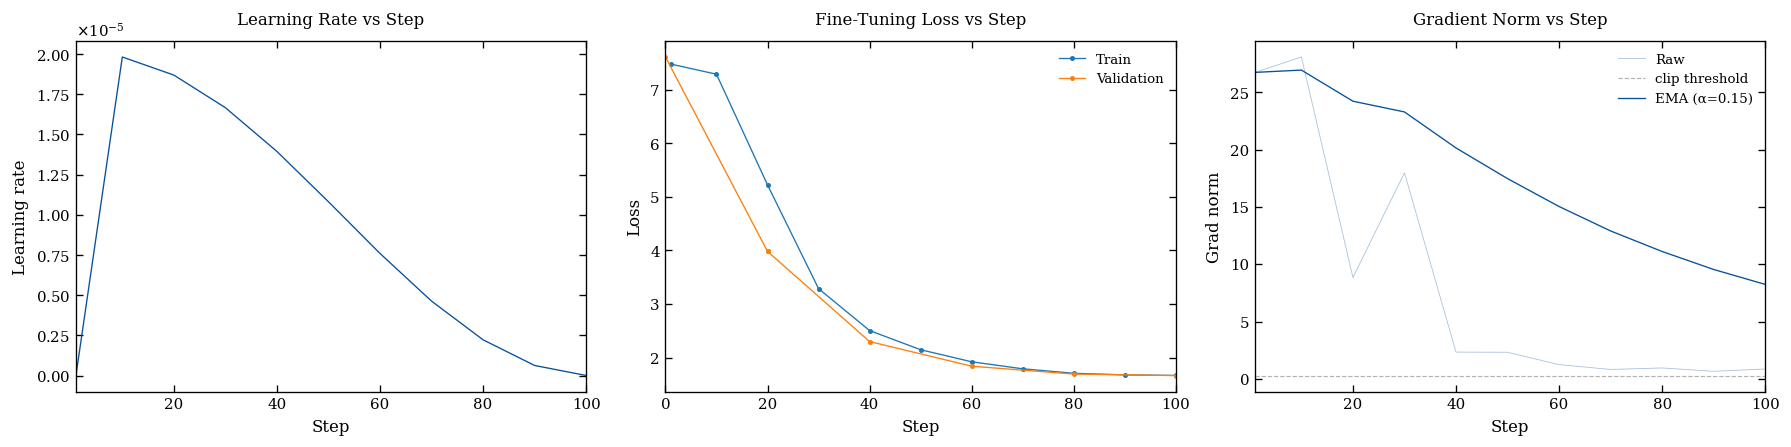

In [ ]:
# @title ### Train and validation losses

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), dpi=120)

for ax in axes:
  ax.spines['top'].set_visible(True)
  ax.spines['right'].set_visible(True)
  ax.tick_params(top=True, right=True, direction='in')

ax = axes[0]
ax.plot(lr_steps, learning_rates, color="#08519c", linewidth=0.8)

ax.set_xlabel("Step")
ax.set_ylabel("Learning rate")
ax.set_title("Learning Rate vs Step", pad=10)

ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
ax.set_xlim(min(lr_steps), max(lr_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[1]
ax.plot(train_steps, train_loss, linewidth=0.8, label="Train", marker='o', markersize=2,)
ax.plot(eval_steps, eval_loss, linewidth=0.8, label="Validation", marker='o', markersize=2,)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Fine-Tuning Loss vs Step", pad=10)
all_steps = train_steps + eval_steps
ax.set_xlim(min(all_steps), max(all_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

ax = axes[2]
ax.plot(grad_steps, grad_norms, color="#08519c", linewidth=0.5, alpha=0.35, label="Raw")
ax.axhline(0.3, color="gray", linewidth=0.7, linestyle="--", alpha=0.6, label="clip threshold")
ax.plot(grad_steps, ema(grad_norms), color="#08519c", linewidth=0.8, label="EMA (α=0.15)")

ax.set_xlabel("Step")
ax.set_ylabel("Grad norm")
ax.set_title("Gradient Norm vs Step", pad=10)
ax.set_xlim(min(grad_steps), max(grad_steps))
ax.margins(x=0.01)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(training_plots_pdf, bbox_inches="tight")
fig.savefig(training_plots_img, bbox_inches="tight", dpi=600)
plt.show()

In [ ]:
# @title
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(LOG_DIR.glob("events.out.tfevents.*"))

print(f"Found {len(event_files)} event file(s)")

metrics = [
  "lora/adapter_param_count",
  "lora/adapter_param_norm",
  "lora/adapter_update_norm",
  "lora/max_layer_update_norm",
]

rows = []

for event_file in event_files:
  ea = EventAccumulator(str(event_file))
  ea.Reload()

  for metric in metrics:
    if metric in ea.Tags()["scalars"]:
      for event in ea.Scalars(metric):
        rows.append({
          "step": event.step,
          "metric": metric.replace("lora/", ""),
          "value": event.value,
        })

lora_df = (
  pd.DataFrame(rows)
  .pivot_table(index="step", columns="metric", values="value", aggfunc="last")
  .reset_index()
  .sort_values("step")
)

lora_df.head(3)

Found 1 event file(s)


metric,step,adapter_param_count,adapter_param_norm,adapter_update_norm,max_layer_update_norm
0,21,133616896.0,56.673634,0.970735,0.111325
1,22,NaN,56.679466,1.012170,0.114476
2,23,NaN,56.685551,1.053351,0.117478


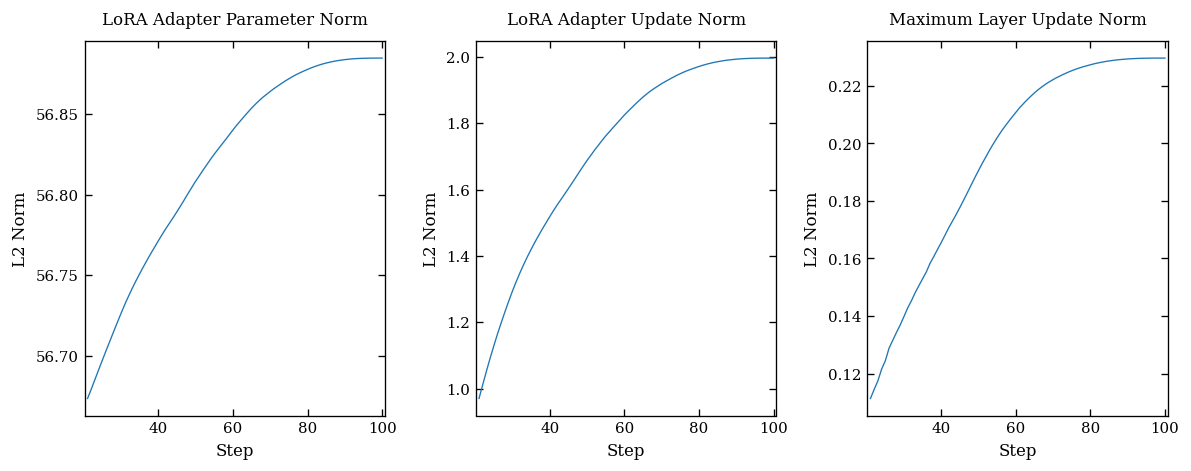

In [ ]:
# @title
plot_info = [
  # ("adapter_param_count", "LoRA Adapter Parameter Count", "Parameters"),
  ("adapter_param_norm", "LoRA Adapter Parameter Norm", "L2 Norm"),
  ("adapter_update_norm", "LoRA Adapter Update Norm", "L2 Norm"),
  ("max_layer_update_norm", "Maximum Layer Update Norm", "L2 Norm"),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), dpi=120,)
axes = axes.ravel()

for ax, (metric, title, ylabel) in zip(axes, plot_info):

  if metric not in lora_df.columns:
    ax.set_visible(False)
    continue

  ax.plot(lora_df["step"], lora_df[metric], linewidth=0.8,)
  ax.set_xlabel("Step")
  ax.set_ylabel(ylabel)
  ax.set_title(title, pad=10)

  ax.spines['top'].set_visible(True)
  ax.spines['right'].set_visible(True)
  ax.tick_params(top=True, right=True, direction='in')
  # ax.grid(axis="y", alpha=0.3)
  ax.margins(x=0.01)

fig.tight_layout()
fig.savefig(lora_stats_pdf, bbox_inches="tight")
fig.savefig(lora_stats_img, bbox_inches="tight", dpi=600)

plt.show()

In [ ]:
# @title Save fine-tuned model
model.save_pretrained(ADAPTER_PATH)
processor.save_pretrained(ADAPTER_PATH)

# model.push_to_hub(HF_HUB_DIR, token = "YOUR_HF_TOKEN")
# processor.push_to_hub(HF_HUB_DIR, token = "YOUR_HF_TOKEN")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/gemma4_31b_high-entropy-alloy_lora/tokenizer_config.json.


['/content/drive/MyDrive/Colab Notebooks/HEA/gemma4/outputs/16/gemma4_31b_high-entropy-alloy_lora/processor_config.json']

In [ ]:
# @title
SAMPLE_INDEX = 1
sample = dataset["test"][SAMPLE_INDEX]
image = sample["image"].convert("RGB")
instruction = sample["instruction"] + "\n" + sample["input"]

for var in ["trainer", "model", "processor", "inputs", "outputs"]:
  if var in globals():
    del globals()[var]

gc.collect()
torch.cuda.empty_cache()

free_vram = torch.cuda.mem_get_info()[0] / 1e9
total_vram = torch.cuda.mem_get_info()[1] / 1e9
print(f"VRAM Cleared! Available: {free_vram:.2f} GB / {total_vram:.2f} GB")

def run_inference(model_name_or_path, title):
  gc.collect()
  torch.cuda.empty_cache()

  model, processor = FastVisionModel.from_pretrained(
    model_name=model_name_or_path,
    load_in_4bit=True,
    device_map="cuda",
  )


  # model.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))
  # processor.push_to_hub(HF_HUB_DIR, token=userdata.get('HF_TOKEN'))

  FastVisionModel.for_inference(model)

  print("\n")
  print(f"{title} params: {model.num_parameters()/1e9:.3f} B\n")

  messages = [{
    "role": "user",
    "content": [
      {"type": "text", "text": instruction},
      {"type": "image"},
    ],
  }]
  input_text = processor.apply_chat_template(messages, add_generation_prompt=True)
  inputs = processor(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
  ).to("cuda")

  streamer = TextStreamer(processor.tokenizer, skip_prompt=True)

  with torch.inference_mode():
    output = model.generate(
      **inputs,
      streamer=streamer,
      max_new_tokens=2048,
      use_cache=True,
      temperature=1.0,
      top_p=0.95,
      top_k=64,
    )

  print('\n⭐ Done')

  generated = processor.tokenizer.decode(
    output[0, inputs["input_ids"].shape[1]:],
    skip_special_tokens=True,
  )

  del model, processor, inputs, output
  gc.collect()
  torch.cuda.empty_cache()

  return generated

VRAM Cleared! Available: 38.81 GB / 42.41 GB


In [ ]:
sample["response"]

'**Image quality:** Moderate\n\n**Experimental Context:**\n- Material: FeMnNiCrCo high-entropy alloy, equiatomic composition Fe20Mn20Ni20Cr20Co20\n- Microstructure & Processing: Vacuum induction melting and casting; homogenization and recrystallization annealing; rapid water quenching; hot-rolling; pre-charging with H₂; single FCC phase; grain size range of 1–25 µm; uniaxial tensile testing at an initial strain rate of \\(10^{-4}\\ \\mathrm{s^{-1}}\\)\n- Hydrogen Exposure Condition: In-situ electrochemical charging in 0.1 M NaOH + 0.05 g/L CH₄N₂S at pH 13; current density of 15 mA/cm²; charging duration of 12 h; desorbed hydrogen content of 8.01 wppm\n\n**Visual observations:**\n- Surface topography: The surface retains predominantly ductile topographic characteristics, with localized intergranular cracking identified along the edges.\n- Morphological features: Microvoid coalescence features; retained ductile fracture features; localized intergranular fracture at the specimen edges.\n\

In [ ]:
weights = load_file(ADAPTER_PATH / "adapter_model.safetensors")
total_trainable_params = sum(p.numel() for p in weights.values())

print(f"Trainable Parameters: {total_trainable_params:,}")

Trainable Parameters: 133,616,896


In [ ]:
# @title ### Base inference
base_response = run_inference(BASE_MODEL, "Base model")

==((====))==  Unsloth 2026.9.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]



Base model params: 31.273 B

# Failure Analysis Report: HEA Sample (FeMnNiCrCo)

**Sample ID:** HEA-FCC-H2-01  
**Material:** Equiatomic FeMnNiCrCo (Cantor Alloy)  
**Condition:** VIM Casting $\rightarrow$ Homogenized/Annealed $\rightarrow$ Hot-rolled $\rightarrow$ H2 Pre-charged

---

### 1. Visual Assessment
*   **Image Quality Rating:** 7/10. The contrast is adequate for feature identification, though some regions exhibit mild over-saturation (blooming) in the highlighted areas. The scale bar is clear and legible.
*   **Morphological Overview:** The fractograph exhibits a mixed-mode morphology. There is a clear transition from relatively smooth, quasi-cleavage platforms to regions of dense, equiaxed micro-voids.
*   **Quantified Dimple Size:** 
    *   Measured against the $4\mu\text{m}$ scale bar, the dimples range from approximately **$0.5\mu\text{m}$ to $1.8\mu\text{m}$** in diameter.
    *   The smaller dimples are concentrated in the localized "honeycomb" clusters, while larg

In [ ]:
# @title ### Fine-tuned inference

ft_response  = run_inference(str(ADAPTER_PATH), "Fine-tuned model")

==((====))==  Unsloth 2026.9.4: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/1188 [00:00<?, ?it/s]



Fine-tuned model params: 31.407 B

<|channel>thought
<channel|>**FAILURE ANALYSIS REPORT**

**Sample ID:** FeMnNiCrCo (Equiatomic)
**Condition:** Pre-charged with $H_2$, Hot-rolled, Water Quenched
**Technique:** SEM (Scan Resolution: $4\mu\text{m}$)

---

### 1. Visual Assessment
*   **Image Quality Rating:** 3/5 (Moderate). While the topography is visible, there is significant charging/brightness variance and lack of sharp contrast at the dimple edges.
*   **Observation:** The fractograph displays a mixed morphology. There is a transition from relatively flat, quasi-cleavage areas to regions of high-density micro-void coalescence.
*   **Absence List:** No evidence of macro-scale intergranular cracking, no secondary phases, no inclusions/precipitates identified at this magnification, and no evidence of fatigue striations.

### 2. Fracture Characterization
*   **Classification:** Mixed Mode $\rightarrow$ **MVC + QC** (Micro-void Coalescence and Quasi-cleavage).
*   **Quantification:**

In [ ]:
from huggingface_hub import HfApi

api = HfApi(token=userdata.get("HF_TOKEN"))

api.move_repo(
    from_id="eneotu/gemma4_e2b_high-entropy-alloy_lora",
    to_id="eneotu/gemma4_31b_high_entropy_alloy_lora",
    repo_type="model",
)

TimeoutException: Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
# @title ### DeepEval

visual_metric = GEval(
  name="Visual",
  # model="gpt-5.6-luna",
  criteria="Check if the output describes visual, spatial, or topographical features.",
  evaluation_params=[
    LLMTestCaseParams.INPUT,
    LLMTestCaseParams.ACTUAL_OUTPUT,
    LLMTestCaseParams.EXPECTED_OUTPUT,
  ],
)

fracture_metric = GEval(
  name="Characterization",
  # model="gpt-5.6-luna",
  criteria="Assess whether fracture morphology features are accurately categorized.",
  evaluation_params=[
    LLMTestCaseParams.ACTUAL_OUTPUT,
    LLMTestCaseParams.EXPECTED_OUTPUT,
  ],
)

mechanistic_metric = GEval(
  name="Mechanistic",
  # model="gpt-5.6-luna",
  criteria="Evaluate whether the physical failure mechanisms are logically derived.",
  evaluation_params=[
    LLMTestCaseParams.ACTUAL_OUTPUT,
    LLMTestCaseParams.EXPECTED_OUTPUT,
  ],
)

HE_metric = GEval(
  name="HE",
  # model="gpt-5.6-luna",
  criteria="Verify that the final Hydrogen Embrittlement evidence level is explicitly stated with a clear justification.",
  evaluation_params=[
    LLMTestCaseParams.ACTUAL_OUTPUT,
    LLMTestCaseParams.EXPECTED_OUTPUT,
  ],
)

In [ ]:
workflow_metric = GEval(
  name="Workflow Adherence",
  # model="gpt-5.6-luna",
  criteria="Evaluate whether the failure analysis report follows the strict sequential flow: 1. Visual Assessment -> 2. Fracture Characterization -> 3. Mechanistic Interpretation -> 4. Hydrogen Embrittlement Assessment & Confidence. All four sections must be clearly addressed and microstructurally sound.",
  evaluation_steps=[
    "Verify that Visual Assessment covers macro/micro surface features."
    "Confirm Fracture Characterization identifies specific fracture modes (e.g., cleavage, quasi-cleavage, dimples)."
    "Check that Mechanistic Interpretation provides stress/crack propagation physics."
    "Check that Hydrogen Embrittlement Assessment states an evidence and confidence level."
  ],
  evaluation_params=[
    LLMTestCaseParams.INPUT,
    LLMTestCaseParams.ACTUAL_OUTPUT,
    LLMTestCaseParams.EXPECTED_OUTPUT,
  ],
)

relevancy_metric = AnswerRelevancyMetric(
  threshold=0.7,
  include_reason=True,
  # model="gpt-5.6-luna",
)

In [ ]:

def pil_to_mllm_image(pil_image: Image.Image) -> MLLMImage:
  buffer = io.BytesIO()
  pil_image.save(buffer, format="PNG")

  img_base64 = base64.b64encode(
    buffer.getvalue()
  ).decode("ascii")

  return MLLMImage(
    dataBase64=img_base64,
    mimeType="image/png",
  )

image = pil_to_mllm_image(sample["image"])

In [ ]:
base_model_test_case = LLMTestCase(
  input=f'{sample["instruction"]} {image}',
  actual_output=base_response,
  expected_output=sample["response"],
  multimodal=True,
)

fine_tuned_test_case = LLMTestCase(
  input=f'{sample["instruction"]} {image}',
  actual_output=ft_response,
  expected_output=sample["response"],
  multimodal=True,
)

eval_results = evaluate(
  test_cases=[
    base_model_test_case,
    fine_tuned_test_case
  ],
  metrics=[
    visual_metric,
    fracture_metric,
    mechanistic_metric,
    HE_metric,
    workflow_metric,
    relevancy_metric,
  ],
)

In [ ]:
print("\n========== DEBUG ==========")
for i, result in enumerate(eval_results.test_results):
  print(f"\n----- test_results[{i}] -----")
  print(result.actual_output[:600])

In [ ]:
def extract_metric_scores(test_result):
  return {
    metric.name: round(metric.score * 100, 2)
    for metric in test_result.metrics_data
  }

base_scores = extract_metric_scores(eval_results.test_results[0])
fine_tuned_scores = extract_metric_scores(eval_results.test_results[1])

df_results = pd.DataFrame([
  {
    "Model": "Base",
    "Visual": base_scores["Visual [GEval]"],
    "Characterization": base_scores["Characterization [GEval]"],
    "Mechanistic": base_scores["Mechanistic [GEval]"],
    "HE": base_scores["HE [GEval]"],
    "Workflow": base_scores["Workflow Adherence [GEval]"],
  },
  {
    "Model": "Fine-tuned",
    "Visual": fine_tuned_scores["Visual [GEval]"],
    "Characterization": fine_tuned_scores["Characterization [GEval]"],
    "Mechanistic": fine_tuned_scores["Mechanistic [GEval]"],
    "HE": fine_tuned_scores["HE [GEval]"],
    "Workflow": fine_tuned_scores["Workflow Adherence [GEval]"],
  },
])

df_results.to_excel(deepeval_xlsx, index=False)
df_results

In [ ]:
metrics = ["Visual", "Characterization", "Mechanistic", "HE", "Workflow"]
colors = ["#7B68EE", "#E74C3C", "#2ECC71", "#3498DB", "#F1C40F",]

fig, ax = plt.subplots(figsize=(5.5, 3.8), dpi=120)
df_results.set_index("Model")[metrics].plot(kind="bar", ax=ax, color=colors, width=0.8,)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("Base vs Fine-tuned", pad=10)
ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False,loc="upper right",)
ax.grid(axis="y", alpha=0.3, linewidth=0.6,)

fig.tight_layout()
fig.savefig(deepeval_pdf, bbox_inches="tight")
fig.savefig(deepeval_img, bbox_inches="tight", dpi=600)
plt.show()

# lmms_eval

In [ ]:
# @title
%%writefile /content/lmms-eval/lmms_eval/models/chat/gemma4_lora.py

import re
import torch
from PIL import Image
from unsloth import FastVisionModel

from lmms_eval.api.registry import register_model
from lmms_eval.api.model import lmms
from lmms_eval.api.instance import Instance


@register_model("gemma4_lora")
class Gemma4Lora(lmms):
  is_simple = False

  def __init__(
    self,
    pretrained: str = "unsloth/gemma-4-31b-it",
    adapter_path: str = None,
    load_in_4bit: bool = True,
    device: str = "cuda",
    **kwargs,
  ):
    super().__init__()
    self.device = device if torch.cuda.is_available() else "cpu"

    model, processor = FastVisionModel.from_pretrained(
      model_name=pretrained,
      load_in_4bit=load_in_4bit,
      offload_buffers=True,
      max_seq_length=2048,
    )

    if adapter_path:
      from peft import PeftModel
      model = PeftModel.from_pretrained(model, adapter_path)

    FastVisionModel.for_inference(model)

    self.model = model
    self.processor = processor
    self.max_new_tokens = kwargs.get("max_new_tokens", 512)

  def _load_pil(self, img):
    if img is None:
        return None
    if isinstance(img, str):
        return Image.open(img).convert("RGB")
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    try:
        return img.convert("RGB")
    except:
        return Image.fromarray(img).convert("RGB")

  def generate_until(self, requests):
    responses = []
    print(f"\nStarting generation of {len(requests)} requests")

    for i, request in enumerate(requests):
        print(f"\nProcessing sample {i+1}/{len(requests)}")
        args = request.args

        images_list = []
        text_prompt = ""

        if len(args) == 5:
          doc_to_messages, gen_kwargs, doc_id, task, split = args
          doc = self.task_dict[task][split][doc_id]
          raw_messages = doc_to_messages(doc)

          from lmms_eval.protocol import ChatMessages
          messages_obj = ChatMessages(messages=raw_messages)
          pil_images, videos, audios = messages_obj.extract_media()
          images_list = [self._load_pil(x) for x in pil_images if x is not None]

          hf_messages = messages_obj.to_hf_messages()
          input_text = self.processor.apply_chat_template(
            hf_messages,
            add_generation_prompt=True,
          )

        elif len(args) == 6:
            prompt, doc_to_messages, gen_kwargs, doc_id, task, split = args
            doc = self.task_dict[task][split][doc_id]

            for key in [f"image_{j}" for j in range(1, 8)] + ["image", "images"]:
                if key in doc and doc[key] is not None:
                    val = doc[key]
                    if isinstance(val, list):
                        for v in val:
                            if v is not None:
                                pil = self._load_pil(v)
                                if pil:
                                    images_list.append(pil)
                    else:
                        pil = self._load_pil(val)
                        if pil:
                            images_list.append(pil)
            seen = set()
            uniq = []
            for im in images_list:
                if id(im) not in seen:
                    uniq.append(im)
                    seen.add(id(im))
            images_list = uniq

            text_prompt = re.sub(r"<image\s*\d+>", "", prompt, flags=re.IGNORECASE).strip()
            text_prompt = text_prompt.replace("<image>", "").strip()

            content = [{"type": "text", "text": text_prompt}]
            for _ in images_list:
                content.append({"type": "image"})

            messages = [{"role": "user", "content": content}]
            input_text = self.processor.apply_chat_template(
              messages,
              add_generation_prompt=True,
            )
        else:
            raise ValueError(f"Unexpected number of args: {len(args)}")

        if not images_list:
            raise RuntimeError(
              f"[Gemma4] No image found for {task}/{split}/{doc_id}. Doc keys: {list(doc.keys())}"
            )

        inputs = self.processor(
          images=images_list,
          text=input_text,
          add_special_tokens=False,
          return_tensors="pt",
        )

        inputs = {
          k: v.to(self.model.device) if torch.is_tensor(v) else v
          for k, v in inputs.items()
        }

        generation_kwargs = dict(gen_kwargs)
        generation_kwargs.pop("until", None)
        generation_kwargs.setdefault("max_new_tokens", self.max_new_tokens)
        generation_kwargs.setdefault("do_sample", False)
        generation_kwargs["use_cache"] = True
        generation_kwargs.setdefault("pad_token_id", self.processor.tokenizer.eos_token_id)

        if not generation_kwargs.get("do_sample", False):
          generation_kwargs.pop("temperature", None)
          generation_kwargs.pop("top_p", None)
          generation_kwargs.pop("top_k", None)

        with torch.inference_mode():
          output_ids = self.model.generate(**inputs, **generation_kwargs)

        input_len = inputs["input_ids"].shape[-1]
        generated_ids = output_ids[:, input_len:]

        # If model generated only 1 token and it's EOS, log prompt for debug
        if generated_ids.shape[-1] <= 1:
          print(f"WARNING: Sample {i+1} generated only {generated_ids.shape[-1]} tokens. Prompt: {input_text[:300]}")

        response = self.processor.tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
        until = gen_kwargs.get("until", [])
        for stop in until:
          if stop and stop in response:
            response = response.split(stop)[0].strip()
        print(f"Sample {i+1} done. Response length: {len(response)}")
        responses.append(response)

    return responses

  def loglikelihood(self, requests: list[Instance]) -> list[tuple[float, bool]]:
    raise NotImplementedError("loglikelihood not implemented")

  def generate_until_multi_round(self, requests: list[Instance]) -> list[str]:
    raise NotImplementedError("generate_until_multi_round not implemented")

In [ ]:
# @title
import lmms_eval.models as models
from lmms_eval.models.registry_v2 import ModelManifest
import lmms_eval.models.chat.gemma4_lora
import importlib


importlib.reload(lmms_eval.models.chat.gemma4_lora)

base_manifest = ModelManifest(
  model_id="gemma4_base",
  simple_class_path="lmms_eval.models.chat.gemma4_lora.Gemma4Lora",
  chat_class_path="lmms_eval.models.chat.gemma4_lora.Gemma4Lora",
  aliases=("gemma4_base",),
)

models.MODEL_REGISTRY_V2.register_manifest(
  base_manifest,
  overwrite=True,
)

lora_manifest = ModelManifest(
  model_id="gemma4_lora",
  simple_class_path="lmms_eval.models.chat.gemma4_lora.Gemma4Lora",
  chat_class_path="lmms_eval.models.chat.gemma4_lora.Gemma4Lora",
  aliases=("gemma4_lora",),
)

models.MODEL_REGISTRY_V2.register_manifest(
  lora_manifest,
  overwrite=True,
)

print(
  "Base registered:",
  "gemma4_base" in models.MODEL_REGISTRY_V2.list_model_names(),
)

print(
  "LoRA registered:",
  "gemma4_lora" in models.MODEL_REGISTRY_V2.list_model_names(),
)

In [ ]:
# @title Base model (MMMU)

from lmms_eval.__main__ import cli_evaluate

sys.argv = [
  "lmms_eval",
  "--model", "gemma4_base",
  "--model_args", f"pretrained={BASE_MODEL}",
  "--tasks", "mmmu_val",
  "--batch_size", "1",
  "--gen_kwargs", "max_new_tokens=256,do_sample=False",
  "--limit", "10",
  "--verbosity", "DEBUG",
  "--log_samples",
  "--output_path", f"{base_lmms_eval_dir}",
]

cli_evaluate()

In [ ]:
 # @title Fine-tuned model (MMMU)

from lmms_eval.__main__ import cli_evaluate

sys.argv = [
  "lmms_eval",
  "--model", "gemma4_lora",
  "--model_args", f"pretrained={BASE_MODEL},adapter_path={ADAPTER_PATH}",
  "--tasks", "mmmu_val",
  "--batch_size", "1",
  "--gen_kwargs", "max_new_tokens=256,do_sample=False",
  "--limit", "10",
  "--verbosity", "DEBUG",
  "--log_samples",
  "--output_path", f"{fine_tuned_lmms_eval_dir}",
]

cli_evaluate()

In [ ]:
base_json_files = list(base_lmms_eval_dir.rglob("*_results.json"))
fine_tuned_json_files = list(fine_tuned_lmms_eval_dir.rglob("*_results.json"))

if not base_json_files:
  raise FileNotFoundError(
    f"No result JSON files found in {base_lmms_eval_dir}"
  )

if not fine_tuned_json_files:
  raise FileNotFoundError(
    f"No result JSON files found in {fine_tuned_lmms_eval_dir}"
  )

fine_tuned_lmms_eval_path = max(fine_tuned_json_files, key=lambda f: f.stat().st_mtime,)
fine_tuned_df = pd.read_json(fine_tuned_lmms_eval_path)

base_lmms_eval_path = max(base_json_files, key=lambda f: f.stat().st_mtime)
base_df = pd.read_json(base_lmms_eval_path)

In [ ]:
base_mmmu = base_df.loc["mmmu_val", "results"]["mmmu_acc,none"]
fine_tuned_mmmu = fine_tuned_df.loc["mmmu_val", "results"]["mmmu_acc,none"]

print(base_mmmu)

In [ ]:
lmms_eval_df = pd.DataFrame([
  {
    "Model": "Base",
    "MMMU": base_mmmu * 100,
  },
  {
    "Model": "Base + Fine-tuned",
    "MMMU": fine_tuned_mmmu * 100,
  },
])

lmms_eval_df.to_excel(lmms_eval_xlsx, index=False)

lmms_eval_df

In [ ]:
metrics = ["MMMU", "MME"]

fig, ax = plt.subplots(figsize=(5.5, 3.8), dpi=120)
lmms_eval_df.set_index("Model")[metrics].plot(kind="bar", ax=ax, width=0.7,)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("Base vs Fine-tuned", pad=10)
ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3, linewidth=0.6,)

ax.set_axisbelow(True)
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False,loc="upper right",)

fig.tight_layout()
fig.savefig(lmms_eval_pdf, bbox_inches="tight")
fig.savefig(lmms_eval_img, bbox_inches="tight", dpi=600)
plt.show()